In [12]:
 #Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier#(based on decision tree(multiple trees))
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler




In [14]:
#2.Load Dataset
df = pd.read_csv("creditcard.csv")
print(df.head())
print(df['Class'].value_counts())  



   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [16]:
#Preprocessing
X = df.drop("Class", axis=1)
y = df["Class"]

if 'Amount' in X.columns:
    scaler = StandardScaler()
    X[['Amount']] = scaler.fit_transform(X[['Amount']])

if 'Time' in X.columns:
    X[['Time']] = scaler.fit_transform(X[['Time']])

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [18]:
#Model Training and Evaluation Function
def train_and_evaluate(X_train, y_train, X_test, y_test):
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    roc = roc_auc_score(y_test, y_prob)
    print("ROC AUC Score:", roc)
    return roc


In [20]:
print("🔵 Without Balancing:")
roc_auc_imbalanced = train_and_evaluate(X_train, y_train, X_test, y_test)


🔵 Without Balancing:
Confusion Matrix:
 [[85290     5]
 [   36   112]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.96      0.76      0.85       148

    accuracy                           1.00     85443
   macro avg       0.98      0.88      0.92     85443
weighted avg       1.00      1.00      1.00     85443

ROC AUC Score: 0.9307385892839318


In [11]:
#5.Apply Balancing Technique
#1.Random Oversampling
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_train, y_train)

print("🟢 Random Oversampling:")
roc_auc_ros = train_and_evaluate(X_ros, y_ros, X_test, y_test)


🟢 Random Oversampling:
Confusion Matrix:
 [[85291     4]
 [   38   110]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.96      0.74      0.84       148

    accuracy                           1.00     85443
   macro avg       0.98      0.87      0.92     85443
weighted avg       1.00      1.00      1.00     85443

ROC AUC Score: 0.947368552384966


In [14]:
#2.Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train, y_train)

print("🟠 Random Undersampling:")
roc_auc_rus = train_and_evaluate(X_rus, y_rus, X_test, y_test)


🟠 Random Undersampling:
Confusion Matrix:
 [[83647  1648]
 [   18   130]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.07      0.88      0.13       148

    accuracy                           0.98     85443
   macro avg       0.54      0.93      0.56     85443
weighted avg       1.00      0.98      0.99     85443

ROC AUC Score: 0.9727617822406498


In [13]:
# 3.SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

print("🔴 SMOTE:")
roc_auc_smote = train_and_evaluate(X_smote, y_smote, X_test, y_test)


🔴 SMOTE:
Confusion Matrix:
 [[85277    18]
 [   31   117]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.87      0.79      0.83       148

    accuracy                           1.00     85443
   macro avg       0.93      0.90      0.91     85443
weighted avg       1.00      1.00      1.00     85443

ROC AUC Score: 0.9512425477238772


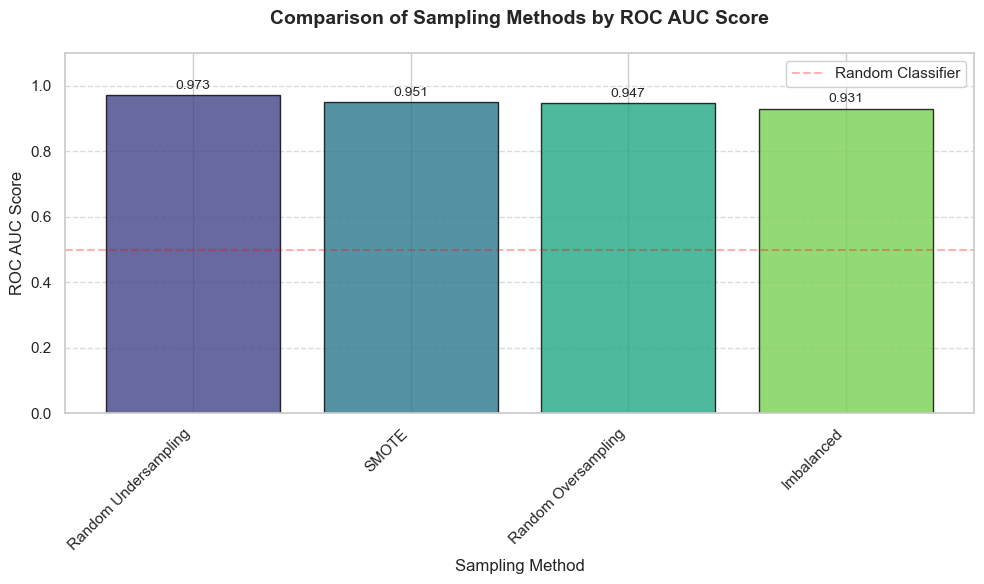

In [23]:
results = {
    'Imbalanced': roc_auc_imbalanced,
    'Random Oversampling': roc_auc_ros,
    'Random Undersampling': roc_auc_rus,
    'SMOTE': roc_auc_smote,
}

results_df = pd.DataFrame.from_dict(results, orient='index', columns=['ROC AUC'])

results_df = results_df.sort_values('ROC AUC', ascending=False)

plt.figure(figsize=(10, 6))

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(results_df)))

bars = plt.bar(results_df.index, results_df['ROC AUC'], 
               color=colors, edgecolor='black', alpha=0.8)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}',
             ha='center', va='bottom', fontsize=10)

plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.3, label='Random Classifier')

plt.title("Comparison of Sampling Methods by ROC AUC Score\n", fontsize=14, fontweight='bold')
plt.ylabel("ROC AUC Score", fontsize=12)
plt.xlabel("Sampling Method", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.1)  # Leave space for value labels
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.legend(loc='upper right', framealpha=0.9)

plt.tight_layout()

plt.show()

/var/folders/lq/n3m2sf557hs8qx5jhql2j9k40000gn/T/ipykernel_29073/3419417335.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('plasma')
/var/folders/lq/n3m2sf557hs8qx5jhql2j9k40000gn/T/ipykernel_29073/3419417335.py:55: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  center_circle = plt.Circle((0,0), 0.1, transform=ax.transData._b,


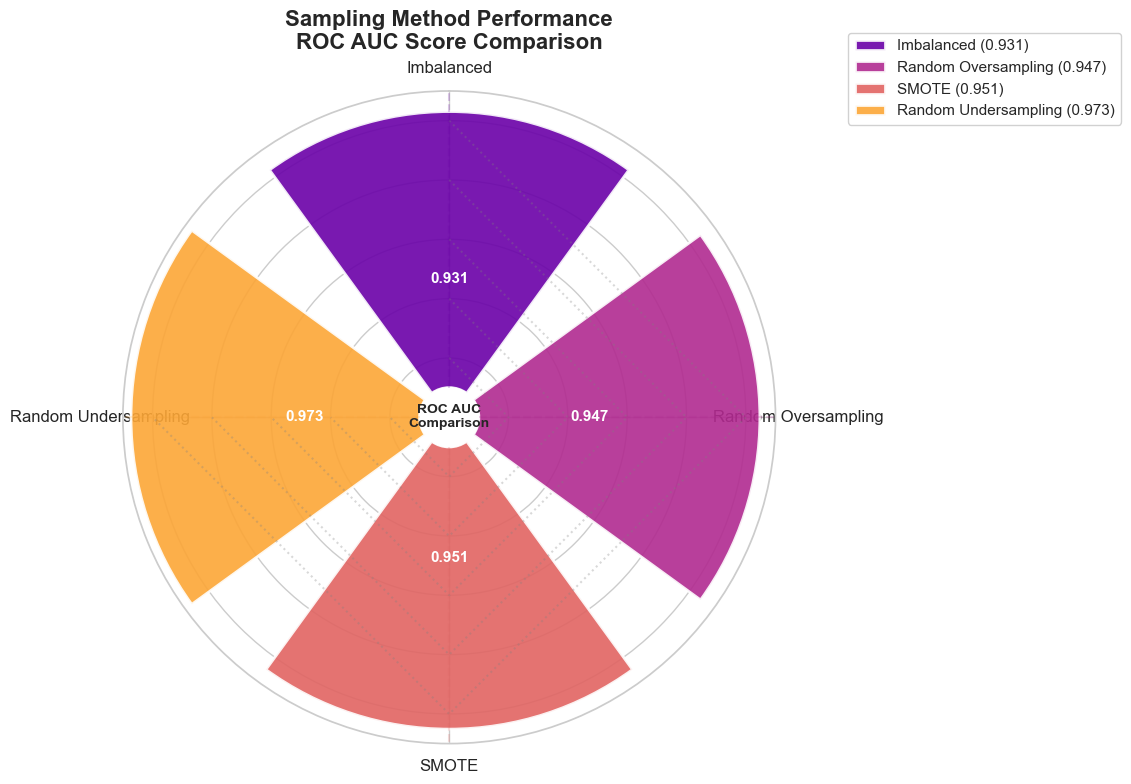

In [27]:
from matplotlib.cm import get_cmap
from matplotlib.patches import Wedge

results = {
    'Imbalanced': roc_auc_imbalanced,
    'Random Oversampling': roc_auc_ros,
    'Random Undersampling': roc_auc_rus,
    'SMOTE': roc_auc_smote,
}
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['ROC AUC'])
results_df = results_df.sort_values('ROC AUC', ascending=True)  # Sort ascending for this visualization
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw=dict(polar=True))

cmap = get_cmap('plasma')
colors = cmap(np.linspace(0.2, 0.8, len(results_df)))

theta = np.linspace(0, 2*np.pi, len(results_df), endpoint=False)
width = 2*np.pi / len(results_df) * 0.8

for i, (index, row) in enumerate(results_df.iterrows()):
    ax.bar(theta[i], row['ROC AUC'], width=width, bottom=0.1,
           color=colors[i], edgecolor='white', linewidth=2, alpha=0.9,
           label=f"{index} ({row['ROC AUC']:.3f})")

    ax.text(theta[i], row['ROC AUC']/2, f"{row['ROC AUC']:.3f}", 
            ha='center', va='center', color='white', fontsize=11, fontweight='bold')
for r in [0.2, 0.4, 0.6, 0.8, 1.0]:
    ax.plot(theta, [r]*len(theta), color='gray', linestyle=':', alpha=0.3)

ax.set_theta_offset(np.pi/2)
ax.set_theta_direction(-1)
ax.set_xticks(theta)
ax.set_xticklabels(results_df.index, fontsize=12)
ax.set_yticklabels([])
ax.set_ylim(0, 1.1)

plt.title("Sampling Method Performance\nROC AUC Score Comparison", 
          fontsize=16, fontweight='bold', pad=30)
plt.legend(bbox_to_anchor=(1.1, 1.1), loc='upper left', framealpha=0.9)

# Add center annotation
center_circle = plt.Circle((0,0), 0.1, transform=ax.transData._b, 
                          color='white', edgecolor='gray', linewidth=1)
ax.add_artist(center_circle)
ax.text(0, 0, "ROC AUC\nComparison", ha='center', va='center', 
        fontsize=10, fontweight='bold')

for i in range(len(results_df)):
    ax.plot([theta[i], theta[i]], [0.1, 1.1], color=colors[i], alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()